Check runtime

In [1]:
!nvidia-smi

Mon Feb  9 13:02:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Clone repo

In [2]:
!git clone https://github.com/EnsiyeTahaei/DeepAnT-Time-Series-Anomaly-Detection.git

Cloning into 'DeepAnT-Time-Series-Anomaly-Detection'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 56 (delta 6), reused 24 (delta 6), pack-reused 24 (from 3)
Receiving objects: 100% (56/56), 5.36 MiB | 34.93 MiB/s, done.
Resolving deltas: 100% (6/6), done.


Install dependencies

In [3]:
!pip install -q numpy pandas torch pytorch_lightning scikit-learn matplotlib PyYAML omegaconf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 63.5 MB/s eta 0:00:00


Setup config (bypass argparse which doesn't work in notebooks)

In [4]:
%cd /content/DeepAnT-Time-Series-Anomaly-Detection

/content/DeepAnT-Time-Series-Anomaly-Detection


In [5]:
import os
import random
import logging
import numpy as np
import torch
from omegaconf import OmegaConf

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Load config manually (argparse doesn't work in notebooks)
config = OmegaConf.load("config.yaml")

# Choose your dataset: "air_quality" or "nab"
DATASET = "nab"

cfg = OmegaConf.merge(config.common, config.dataset[DATASET])

# Prepare config
os.makedirs(cfg.run_dir, exist_ok=True)
random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {cfg.device}")
print(OmegaConf.to_yaml(cfg))

Device: cuda
seed: 200
max_initial_steps: 50
max_steps: 500
batch_size: 16
patience: 150
lr: 0.001
hidden_size: 256
run_dir: ${common.run_dir}/nab
dataset_name: NAB
window_size: 10
device: cuda



Load data

In [6]:
from utils.data_utils import load_data

train_dataset, val_dataset, test_dataset, feature_dim = load_data(
    cfg.dataset_name, cfg.window_size, cfg.device
)

print(f"Train: {train_dataset.data_x.shape}")
print(f"Val:   {val_dataset.data_x.shape}")
print(f"Test:  {test_dataset.data_x.shape}")
print(f"Features: {feature_dim}")

Train: (1720, 10, 1)
Val:   (215, 10, 1)
Test:  (216, 10, 1)
Features: 1


Train the model

In [7]:
from deepant.trainer import DeepAnT

model = DeepAnT(cfg, train_dataset, val_dataset, test_dataset, feature_dim)
model.train()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ DeepAntPredictor │ 74.6 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 74.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 74.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ DeepAntPredictor │ 74.6 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 74.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 74.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Detect anomalies & visualize

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

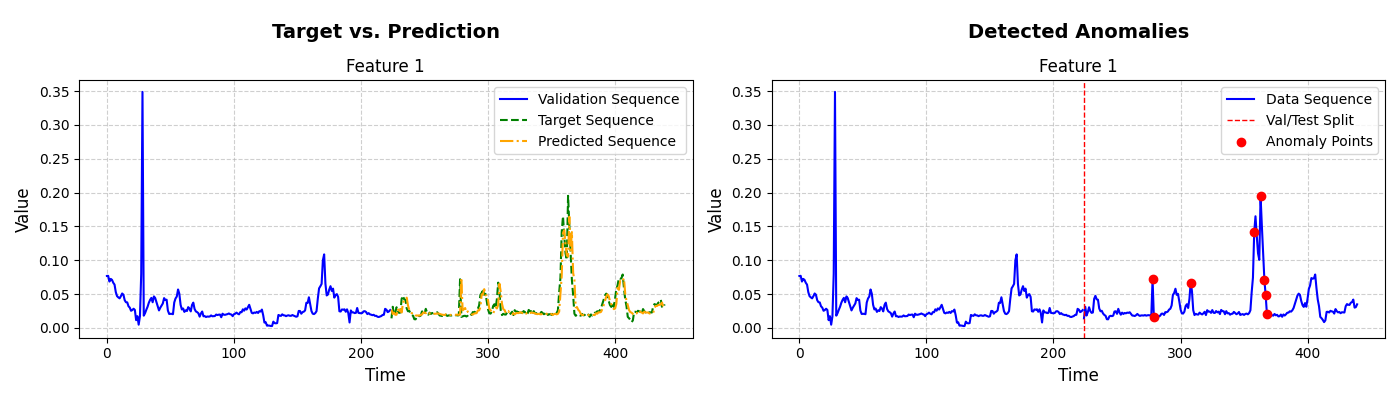

In [8]:
model.detect_anomaly()

# Display the saved plot inline
from IPython.display import Image, display
display(Image(filename=os.path.join(cfg.run_dir, "anomalies_visualization.png")))

## Evaluate Results

**Key checks to verify correctness:**
1. **Training loss convergence** — did val_loss decrease and stabilize?
2. **Prediction quality** — does the predicted sequence track the target?
3. **Anomaly count** — with mean+2σ threshold, expect ~5% of test points flagged
4. **Ground truth comparison** (NAB only) — compute precision, recall, F1

In [2]:
import json
import numpy as np

# --- 1. Check anomaly count ---
with open(os.path.join(cfg.run_dir, "anomalies_indices.json"), "r") as f:
    detected = json.load(f)

test_size = model.test_dataset.data_x.shape[0]
for feature, indices in detected.items():
    pct = len(indices) / test_size * 100
    print(f"{feature}: {len(indices)} anomalies out of {test_size} test points ({pct:.1f}%)")
    if pct > 20:
        print(f"  ⚠️  High anomaly rate — threshold may be too low or model underfitting")
    elif pct == 0:
        print(f"  ⚠️  No anomalies detected — threshold may be too high")

# --- 2. Check prediction error (MAE on test set) ---
from torch.utils.data import DataLoader
import torch

test_loader = DataLoader(model.test_dataset, batch_size=test_size, shuffle=False)
best_model_path = os.path.join(cfg.run_dir, "best_model.ckpt")

from deepant.trainer import AnomalyDetector
best_model = AnomalyDetector.load_from_checkpoint(
    checkpoint_path=best_model_path,
    model=model.deepant_predictor,
    lr=float(cfg.lr)
)
best_model.eval()

with torch.no_grad():
    for x, y in test_loader:
        preds = best_model(x)
        mae = torch.mean(torch.abs(preds - y)).item()
        print(f"\nTest MAE: {mae:.6f}")
        print(f"  (lower = better predictions; compare to data range [0,1] after MinMaxScaler)")

# --- 3. If using NAB dataset: compare with known anomaly windows ---
if DATASET == "nab":
    print("\n--- NAB Ground Truth Comparison ---")
    print("NAB labels for TravelTime_451 can be found at:")
    print("https://github.com/numenta/NAB/blob/master/labels/combined_labels.json")
    print("\nKnown anomaly timestamps for realTraffic/TravelTime_451.csv:")
    # These are the known anomaly timestamps from the NAB benchmark
    nab_known_anomalies = [
        "2015-01-27 00:00:00",
        "2015-02-17 20:25:00",
        "2015-03-15 10:54:00",
    ]
    print(f"  {nab_known_anomalies}")
    print(f"\nYour detected anomaly indices (in test set): {detected}")
    print("To validate: map these indices back to timestamps and check overlap.")
else:
    print("\n--- AirQuality Dataset ---")
    print("No standard ground-truth anomaly labels available.")
    print("Validate by visual inspection: do flagged points look like genuine outliers?")

NameError: name 'os' is not defined